In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Pracitcal 2

In this practical we will explore methods to numerically ’simulate’ differential equations of the form ̇$\dot{x} = f (x)$ and will study the energetics of simple mechanical systems. Simulation involves numerically ’solving’ a differential
equation $\dot{x} = f (x)$ over time. The fundamental idea is that the value of the function at tk+1 equals the value
of the function at tk plus the integral of the derivative in between these time points:
$$ x_{k+1} = x_k + \int_{t_k}^{t_{k+1}} \dot{x} \,dx$$

### 2.1

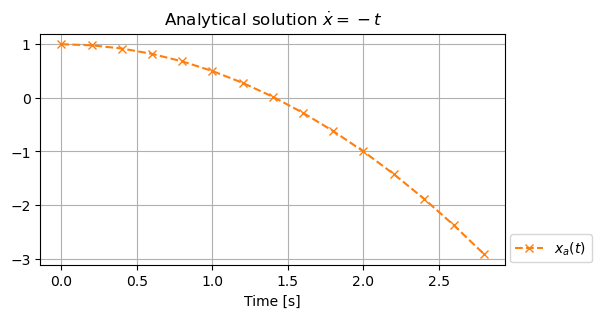

In [2]:
timestep = 0.2

t = np.arange(0, 3, timestep)
dt = t[1] - t[0]
dx = -t
x0 = 1

x = np.zeros(len(t))
x[0] = x0
for i in range(1, len(t)):
    x[i] = x[i-1] + dx[i-1] * dt

# Analytical solution
x_a = -0.5 * t**2 + x0

fig, ax = plt.subplots(figsize=(6, 3))
ax.set_title('Analytical solution $\dot{x} = -t$')
ax.set_xlabel('Time [s]')

# ax.plot(t, x, 'C0x-', label='$x(t)$')
ax.plot(t, x_a, 'C1x--', label=r'$x_a(t)$')
# ax.plot(t, dx, 'C2-', label=r'$\dot{x}(t)$')

ax.legend(loc=(1.01, 0.01))
ax.grid(True)


### 2.2

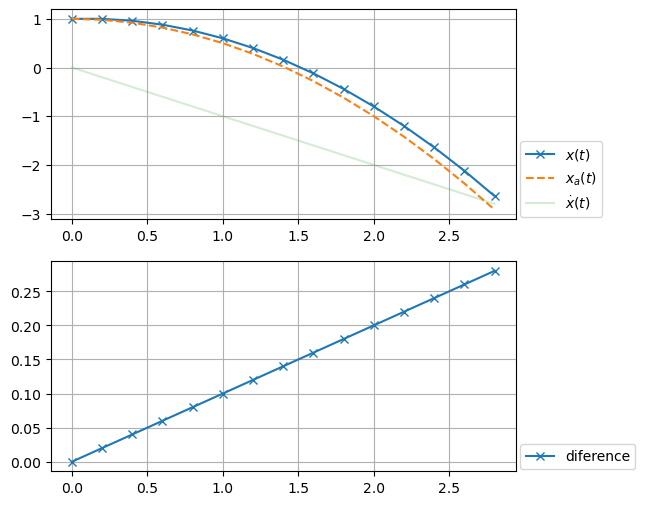

In [3]:
timestep = 0.2

t = np.arange(0, 3, timestep)
dt = t[1] - t[0]
dx = -t
x0 = 1

# Analytical solution
x_a = -0.5 * t**2 + x0


## Euler forward integration
x = np.zeros(len(t))
x[0] = x0
for i in range(1, len(t)):
    x[i] = x[i-1] + dx[i-1] * dt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6,6))
ax.set_xlabel('Time [s]')

ax1.plot(t, x, 'C0x-', label='$x(t)$')
ax1.plot(t, x_a, 'C1--', label=r'$x_a(t)$')
ax1.plot(t, dx, 'C2-', alpha=0.2, label=r'$\dot{x}(t)$')

ax1.legend(loc=(1.01, 0.01))
ax1.grid(True)

ax2.plot(t, abs(x_a - x), 'C0x-', label='diference')
ax2.legend(loc=(1.01, 0.01))
ax2.grid(True)



### 2.3

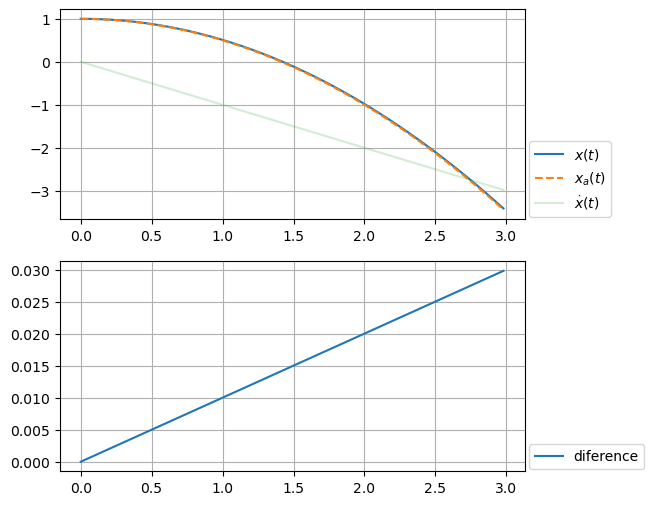

In [4]:
timestep = 0.02

t = np.arange(0, 3, timestep)
dt = t[1] - t[0]
dx = -t
x0 = 1


# Analytical solution
x_a = -0.5 * t**2 + x0


## Euler forward integration
x = np.zeros(len(t))
x[0] = x0
for i in range(1, len(t)):
    x[i] = x[i-1] + dx[i-1] * dt

# Analytical solution
x_a = -0.5 * t**2 + x0

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6,6))
ax.set_xlabel('Time [s]')

ax1.plot(t, x, 'C0-', label='$x(t)$')
ax1.plot(t, x_a, 'C1--', label=r'$x_a(t)$')
ax1.plot(t, dx, 'C2-', alpha=0.2, label=r'$\dot{x}(t)$')

ax1.legend(loc=(1.01, 0.01))
ax1.grid(True)

ax2.plot(t, abs(x_a - x), 'C0', label='diference')
ax2.legend(loc=(1.01, 0.01))
ax2.grid(True)



### 2.4

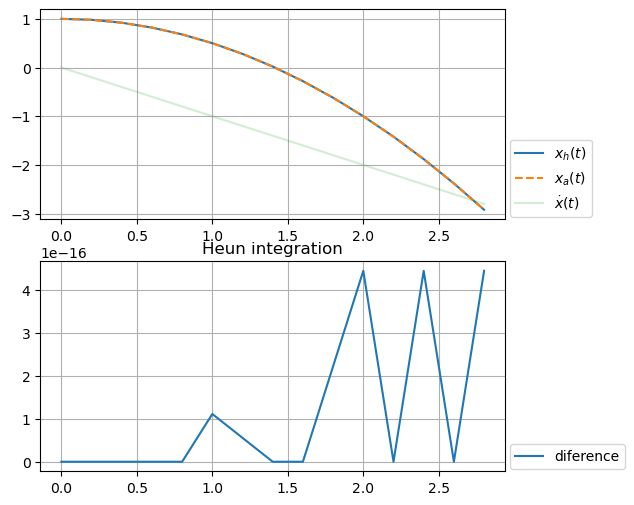

In [5]:
timestep = 0.2

t = np.arange(0, 3, timestep)
dt = t[1] - t[0]
dx = -t
x0 = 1

# Analytical solution
x_a = -0.5 * t**2 + x0

## Heun integration
x_h = np.zeros(len(t))
x_h[0] = x0
for i in range(1, len(t)):
    x_z = x_h[i-1] + dx[i-1] * dt
    x_h[i] = x_h[i-1] + dt * (dx[i-1] + dx[i])/2
    

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6,6))
ax.set_xlabel('Time [s]')

ax1.plot(t, x_h, 'C0-', label='$x_h(t)$')
ax1.plot(t, x_a, 'C1--', label=r'$x_a(t)$')
ax1.plot(t, dx, 'C2-', alpha=0.2, label=r'$\dot{x}(t)$')

ax1.legend(loc=(1.01, 0.01))
ax1.grid(True)


ax2.set_title('Heun integration')
ax2.plot(t, abs(x_a - x_h), 'C0', label='diference')
ax2.legend(loc=(1.01, 0.01))
ax2.grid(True)


### 2.5

In [6]:
from scipy import integrate

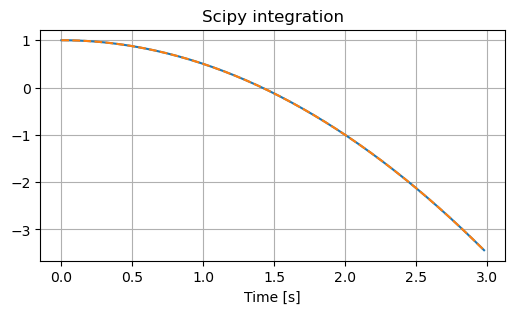

In [7]:
timestep = 0.02

t = np.arange(0, 3, timestep)
dt = t[1] - t[0]


# Analytical solution
x_a = -0.5 * t**2 + x0

def f(t, x):
    return -t

sol = integrate.solve_ivp(f, [0, 3], [1], t_eval=t)
fig, ax = plt.subplots(figsize=(6, 3))
ax.set_title('Scipy integration')
ax.set_xlabel('Time [s]')
ax.grid(True)   
ax.plot(t, sol.y[0], 'C0-', label='$x(t)$')
ax.plot(t, x_a, 'C1--', label=r'$x_analytic(t)$');

### 2.7

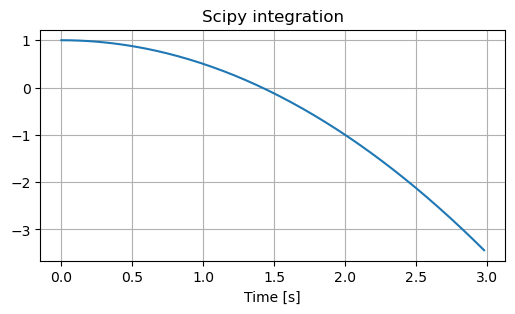

In [8]:
# 3 Example from tutorial 1


sol = integrate.solve_ivp(f, [0, 3], [1, 0, 0], t_eval=t)
fig, ax = plt.subplots(figsize=(6, 3))
ax.set_title('Scipy integration')
ax.set_xlabel('Time [s]')
ax.grid(True)   
ax.plot(t, sol.y[0], 'C0-', label='$x(t)$')